# GHALogs dataset metrics

Execution-verified adaptation of the authors’ dataset metrics. Original aggregation definitions are retained; projected scans reduce transfer without changing counts. Connection and paths are configurable. Full metadata and authors-selected populations are different.

In [1]:
import os, sys, json, gzip, csv, re, random, hashlib, struct, zlib, io, tarfile, time
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import pymongo
from pymongo import ReplaceOne
from bson import BSON
from urllib.request import Request, urlopen
from urllib.error import HTTPError

# Set these environment variables to your own external input/work locations.
# Git tracks only notebooks, provenance, compact results and review templates.
BASE = Path(os.getenv('GHA_DATA_ROOT', '../external_data')).resolve()
OUT = Path(os.getenv('GHA_WORK_ROOT', '../external_work')).resolve()
REPO = Path(os.getenv('GHA_SOURCE_ROOT', str(BASE / 'gha-dataset'))).resolve()
MONGODB_URI = os.getenv('MONGODB_URI', 'mongodb://127.0.0.1:27018')
DB_NAME = os.getenv('GHA_DB_NAME', 'gha-scraper')
assert OUT != BASE and OUT != REPO, 'Outputs must be isolated from inputs/source'
for name in ('metadata_audit', 'java_failure_candidates', 'raw_log_evidence',
             'raw', 'normalized', 'windows', 'cache'):
    (OUT/name).mkdir(exist_ok=True, parents=True)
client = pymongo.MongoClient(MONGODB_URI, serverSelectionTimeoutMS=5000)
display(client.admin.command('ping'))
db = client[DB_NAME]
mongo_repositories = db['repositories']; mongo_runs = db['runs']
def save_json(path, obj):
    path.write_text(json.dumps(obj, indent=2, default=str, ensure_ascii=False), encoding='utf-8')
def save_csv(path, rows):
    pd.DataFrame(rows).to_csv(path, index=False)
def jsonl(path, rows):
    with path.open('w', encoding='utf-8') as fd:
        for row in rows: fd.write(json.dumps(row, default=str, ensure_ascii=False)+'\n')
def get_json(url):
    with urlopen(Request(url, headers={'User-Agent':'GHALogs-publication-exploration'}), timeout=60) as response:
        return json.load(response)
print('Python', sys.version.split()[0], 'MongoDB', client.server_info()['version'])
print('External inputs:', BASE, 'External execution outputs:', OUT)

{'ok': 1.0}

Python 3.12.5 MongoDB 7.0.30
External inputs: D:\SJSU MSDA\DATA298A External execution outputs: D:\SJSU MSDA\DATA298A\ghalogs_publication_work\execution


# 1 - Dataset metrics

This Jupyter notebook shows various dataset metrics presented in the paper.

In [2]:
import gzip
import json
import pymongo
import numpy as np

# scipy import omitted: unused by the authors cells
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from tqdm.auto import tqdm

D:\SJSU MSDA\DATA298A\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
mongo_client = client
mongo_repositories = db["repositories"]
mongo_runs = db["runs"]

In [4]:
# Helper functions
def get_class_ratios(elements):
    n = len(elements)
    for v, c in sorted(Counter(elements).items(), reverse=True, key=lambda x: x[1]):
        pct = round(100*c/n, 2)
        print(f"{c}/{n} ({pct}%) {v}")

In [5]:
# Get various stats
languages_repos = list(
    mongo_repositories.aggregate([
        {'$match': {'selected': True}},
        { "$group": { '_id': "$repo.mainLanguage", 'nb_repositories': {'$sum': 1}}}
    ])
)

languages_runs = list(
    mongo_repositories.aggregate([
        {'$match': {'selected': True}},
        {
          "$lookup":
             {
                'from': "runs",
                'localField': "_id",
                'foreignField': "repository_name",
                'as': "runs"
             }
        },
        {'$unwind': '$runs'},
        {'$match': {'runs.log_insights': {'$exists': True, '$ne': []}}},
        {
            '$group': {
                '_id': '$repo.mainLanguage',
                'nb_runs': {'$sum': 1},
            }
        }
    ])
)

languages_workflows = list(
    mongo_repositories.aggregate([
        {'$match': {'selected': True}},
        {
          "$lookup":
             {
                'from': "runs",
                'localField': "_id",
                'foreignField': "repository_name",
                'as': "runs"
             }
        },
        {'$unwind': '$runs'},
        {'$match': {'runs.log_insights': {'$exists': True, '$ne': []}}},
        {
            '$group': {
                '_id': {'mainLanguage': '$repo.mainLanguage', 'repository_name': '$runs.repository_name', 'workflow_path': '$runs.workflow_path'}              
            }
        },
        {
            '$group': {
                '_id': '$_id.mainLanguage',
                'nb_workflows': {'$sum': 1},
            }
        },
    ])
)

In [6]:
# Print to Latex table
total_repos = sum([x["nb_repositories"] for x in languages_repos])
total_runs = sum([x["nb_runs"] for x in languages_runs])
total_workflows = sum([x["nb_workflows"] for x in languages_workflows])

languages_repos = sorted(languages_repos, key=lambda x: x["nb_repositories"], reverse=True)
languages_runs_dict = {
    x["_id"]: x["nb_runs"] for x in languages_runs
}
languages_workflows_dict = {
    x["_id"]: x["nb_workflows"] for x in languages_workflows
}
for doc in languages_repos:
    language = doc['_id']
    nb_repositories = doc['nb_repositories']

    nb_runs = languages_runs_dict.get(language, 0)
    nb_workflows = languages_workflows_dict.get(language, 0)

    pct_repo = round(100*nb_repositories/total_repos, 2)
    pct_runs = round(100*nb_runs/total_runs, 2)
    pct_workflows = round(100*nb_workflows/total_workflows, 2)

    # Sorry for the uglyx formatting... Next we will use pandas.DataFrame.to_latex() ;)
    print(f"{language} & {str(round(nb_repositories/1000, 2)) + 'k' if nb_repositories>1000 else nb_repositories} ({pct_repo}\\%) & "
          f"{str(round(nb_workflows/1000, 2)) + 'k' if nb_workflows>1000 else nb_workflows} ({pct_workflows}\\%) & " +
          f"{str(round(nb_runs/1000, 2)) + 'k' if nb_runs>1000 else nb_runs} ({pct_runs}\\%) \\\\")

print(f"Total & {round(total_repos/1000, 3)}k & {round(total_workflows/1000, 3)}k & {round(total_runs/1000, 3)}k \\\\")

Python & 5.52k (19.5\%) & 22.34k (19.21\%) & 97.31k (18.95\%) \\
TypeScript & 4.44k (15.66\%) & 18.9k (16.25\%) & 84.19k (16.4\%) \\
Go & 2.95k (10.41\%) & 15.77k (13.56\%) & 70.38k (13.71\%) \\
JavaScript & 2.78k (9.8\%) & 9.78k (8.41\%) & 44.2k (8.61\%) \\
C++ & 2.14k (7.55\%) & 9.22k (7.93\%) & 40.98k (7.98\%) \\
Java & 2.07k (7.32\%) & 8.34k (7.17\%) & 36.66k (7.14\%) \\
Rust & 2.02k (7.14\%) & 7.97k (6.86\%) & 34.9k (6.8\%) \\
C & 1.25k (4.41\%) & 5.17k (4.45\%) & 23.3k (4.54\%) \\
PHP & 1.2k (4.22\%) & 4.56k (3.92\%) & 20.12k (3.92\%) \\
C# & 1.1k (3.88\%) & 3.79k (3.26\%) & 15.88k (3.09\%) \\
Shell & 735 (2.6\%) & 2.71k (2.33\%) & 11.95k (2.33\%) \\
Ruby & 639 (2.26\%) & 2.3k (1.98\%) & 10.45k (2.04\%) \\
Kotlin & 634 (2.24\%) & 2.27k (1.95\%) & 9.72k (1.89\%) \\
Dart & 319 (1.13\%) & 1.38k (1.18\%) & 5.93k (1.15\%) \\
Swift & 250 (0.88\%) & 806 (0.69\%) & 3.29k (0.64\%) \\
Elixir & 126 (0.44\%) & 354 (0.3\%) & 1.56k (0.3\%) \\
Objective-C & 60 (0.21\%) & 275 (0.24\%) & 1.21k (0

In [7]:
# Log parsing stats
parsing_errors = []
for run in tqdm(mongo_runs.find({"log_insights": {"$exists": True, "$ne": []}}, {"log_insights.steps.type":1,"log_insights.steps.error":1,"log_insights.steps.commands":1})):
    for job in run["log_insights"]:
        for step in job.get("steps", []):
            if step["type"] == "shell":
                if step.get("error"):
                    parsing_errors.append(step["error"]["error"])
                else:
                    parsing_errors.append("Success")
get_class_ratios(parsing_errors)

0it [00:00, ?it/s]

102it [00:00, 177.92it/s]

2097it [00:01, 2230.43it/s]

4895it [00:01, 3711.57it/s]

6539it [00:02, 3520.70it/s]

...

514345it [02:18, 2875.53it/s]

515183it [02:19, 2485.86it/s]

517625it [02:19, 3664.04it/s]

517937it [02:19, 3710.25it/s]

6016239/6238737 (96.43%) Success
205807/6238737 (3.3%) Parser exception
16691/6238737 (0.27%) Invalid request


In [8]:
# Log download errors
log_download_errors = []
for run in tqdm(mongo_runs.find({"logs_archive.error": {"$exists": True}}, {"logs_archive.error":1}), leave=False):
    error = run["logs_archive"]["error"]
    if "File name too long" in error:
        error = "File name too long"  # Remove path from error message
    log_download_errors.append(error)
get_class_ratios(log_download_errors)

0it [00:00, ?it/s]

102it [00:08, 11.80it/s]

36653/50846 (72.09%) More than 90d old
8987/50846 (17.67%) Got HTTP 410
4041/50846 (7.95%) Got HTTP 404
636/50846 (1.25%) unexpected end of data
414/50846 (0.81%) Got HTTP 403
51/50846 (0.1%) File name too long
38/50846 (0.07%) cannot access local variable 'req' where it is not associated with a value
17/50846 (0.03%) Logs archive is too big
4/50846 (0.01%) Fail after 5 attempts (HTTP 403)
4/50846 (0.01%) Fail after 5 attempts (HTTP 500)
1/50846 (0.0%) Fail after 5 attempts (HTTP 502)


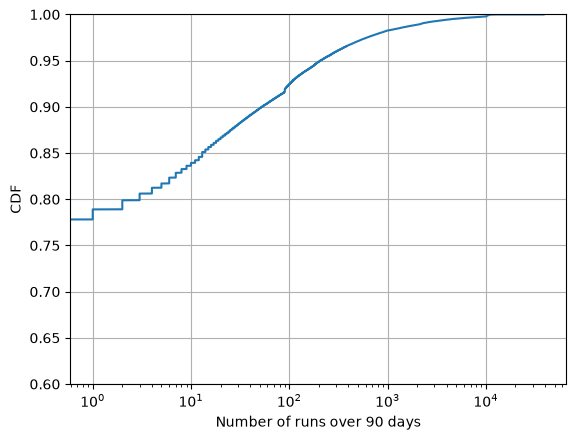

In [9]:
# CDF number of runs over 90d
total_runs = [doc["total_runs_90d"] for doc in mongo_repositories.find({"total_runs_90d": {"$gte": 0}}, projection={"total_runs_90d": True})]

N = len(total_runs)
X = np.sort(total_runs)
Y = np.array(range(N))/float(N)

plt.plot(X, Y)
plt.ylabel("CDF")
plt.xlabel("Number of runs over 90 days")
plt.ylim(0.6, 1)
plt.xscale("log")
plt.grid(True)
# plt.savefig("cdf_repos.png")
plt.show()

In [10]:
# Percentage of commands with at least one annotation
commands_with_annotations = 0
commands_total = 0
for run in tqdm(mongo_runs.find({"log_insights": {"$exists": True, "$ne": []}}, {"log_insights.steps.type":1,"log_insights.steps.error":1,"log_insights.steps.commands":1})):
    for job in run["log_insights"]:
        for step in job.get("steps", []):
             if step["type"] == "shell":
                 for command in step.get("commands", []):
                     commands_total += 1
                     if command.get("annotations", []):
                         commands_with_annotations += 1
print(f"{round(100*commands_with_annotations/commands_total)}% of commands have annotations")

0it [00:00, ?it/s]

102it [00:00, 198.72it/s]

2097it [00:01, 2201.39it/s]

4895it [00:01, 3261.50it/s]

6539it [00:02, 3168.39it/s]

...

514345it [02:27, 2844.87it/s]

515183it [02:27, 2459.32it/s]

517625it [02:28, 3887.20it/s]

517937it [02:28, 3495.19it/s]

71% of commands have annotations
